# **KNN algoithm**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
iris = load_iris(as_frame=True)
df = iris.frame

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Shape: (150, 5)

Missing values:
 0

Class distribution:
 target
0    50
1    50
2    50
Name: count, dtype: int64

Class names: ['setosa' 'versicolor' 'virginica']


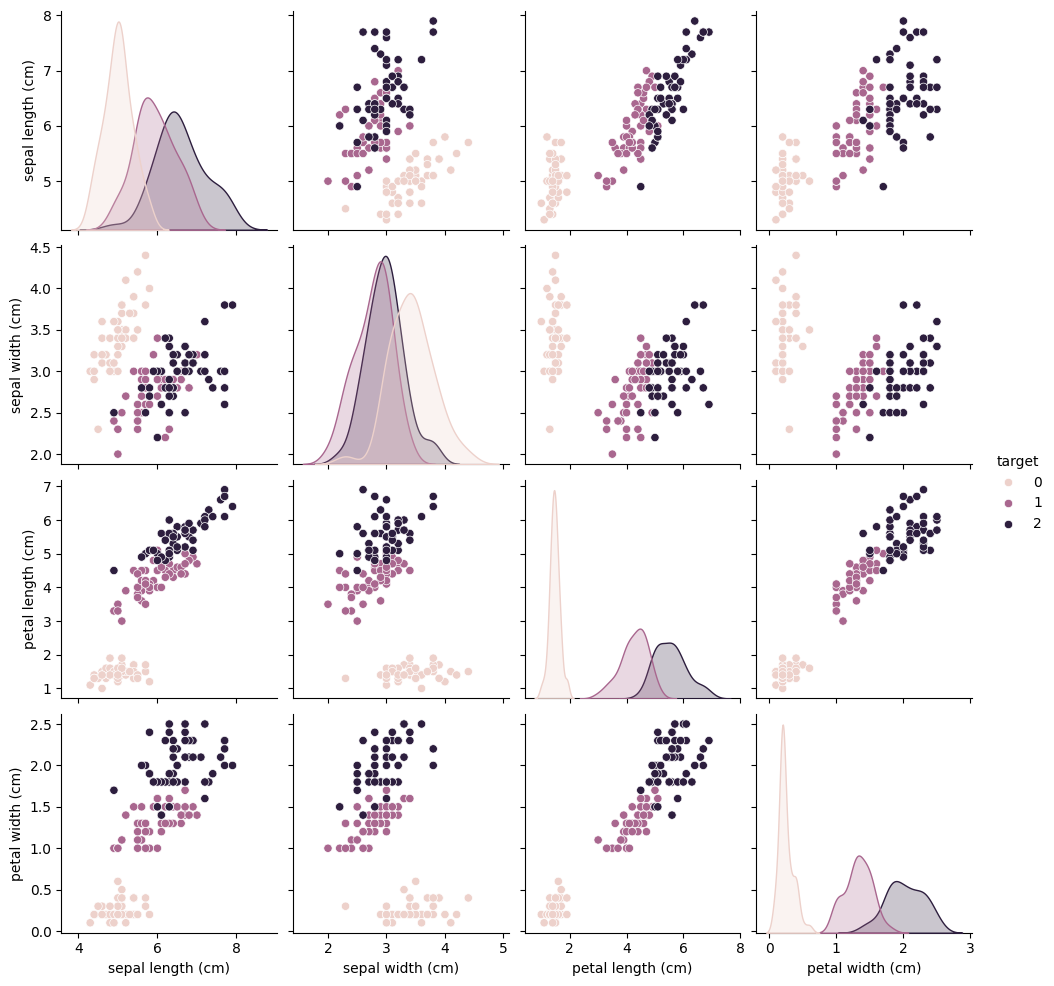

In [ ]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nClass distribution:\n", df["target"].value_counts())
print("\nClass names:", iris.target_names)

# Quick visual - see how features separate the classes
sns.pairplot(df, hue="target", vars=iris.feature_names)
plt.show()

In [ ]:
X = df[iris.feature_names]
y = df["target"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (120, 4)
Test size: (30, 4)


In [ ]:
#scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # learns mean/std from training data only
X_test_scaled = scaler.transform(X_test)          # applies that same transformation to test data

In [ ]:
#Train KNN for a Single K (Baseline Check)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"KNN (K=5) -> Accuracy: {acc:.4f}")

KNN (K=5) -> Accuracy: 0.9333


In [ ]:
#Vary K from 1 to 20, Track Accuracy
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    acc_temp = accuracy_score(y_test, y_pred_temp)
    accuracies.append(acc_temp)
    print(f"K={k:2d} -> Accuracy: {acc_temp:.4f}")

K= 1 -> Accuracy: 0.9667
K= 2 -> Accuracy: 0.9333
K= 3 -> Accuracy: 0.9333
K= 4 -> Accuracy: 0.9333
K= 5 -> Accuracy: 0.9333
K= 6 -> Accuracy: 0.9333
K= 7 -> Accuracy: 0.9667
K= 8 -> Accuracy: 0.9333
K= 9 -> Accuracy: 0.9667
K=10 -> Accuracy: 0.9667
K=11 -> Accuracy: 0.9667
K=12 -> Accuracy: 0.9667
K=13 -> Accuracy: 0.9667
K=14 -> Accuracy: 0.9667
K=15 -> Accuracy: 0.9667
K=16 -> Accuracy: 0.9667
K=17 -> Accuracy: 0.9667
K=18 -> Accuracy: 0.9667
K=19 -> Accuracy: 0.9667
K=20 -> Accuracy: 0.9667


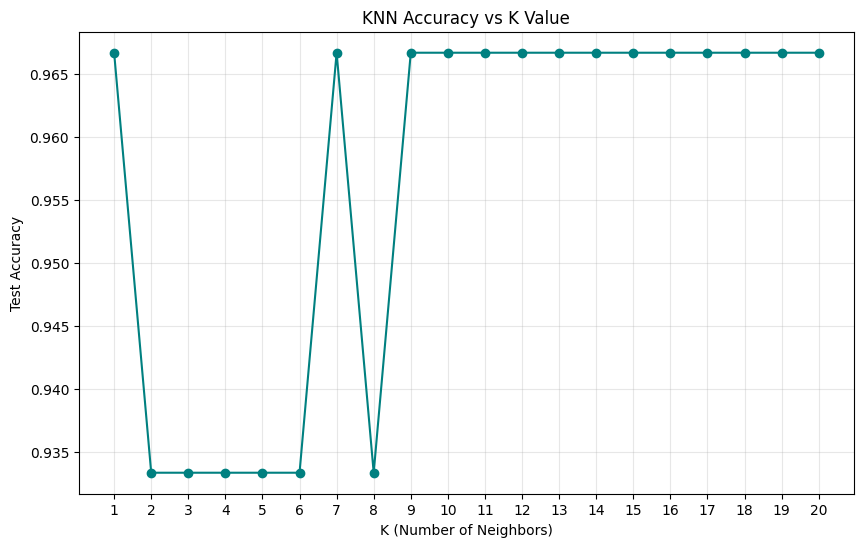

Best K: 1, Best Accuracy: 0.9667


In [ ]:
# plot accuracy vs k
plt.figure(figsize=(10,6))
plt.plot(k_values, accuracies, marker="o", linestyle="-", color="teal")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN Accuracy vs K Value")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Best K: {best_k}, Best Accuracy: {max(accuracies):.4f}")

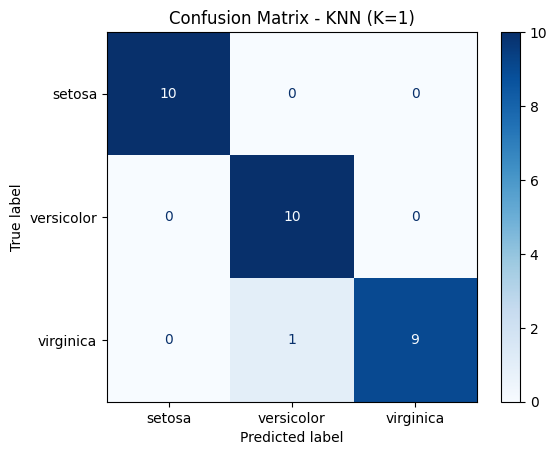

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
#confusion matrix for best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - KNN (K={best_k})")
plt.show()

print(classification_report(y_test, y_pred_best, target_names=iris.target_names))

**Trying out with cross validation**

In [ ]:
# Vary K from 1 to 20, Track Cross-Validated Accuracy
from sklearn.model_selection import cross_val_score

k_values = range(1, 21)
cv_accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5)   # 5-fold CV on training data
    mean_acc = scores.mean()
    cv_accuracies.append(mean_acc)
    print(f"K={k:2d} -> CV Accuracy: {mean_acc:.4f} (+/- {scores.std():.4f})")

K= 1 -> CV Accuracy: 0.9417 (+/- 0.0425)
K= 2 -> CV Accuracy: 0.9583 (+/- 0.0373)
K= 3 -> CV Accuracy: 0.9583 (+/- 0.0373)
K= 4 -> CV Accuracy: 0.9583 (+/- 0.0373)
K= 5 -> CV Accuracy: 0.9667 (+/- 0.0312)
K= 6 -> CV Accuracy: 0.9667 (+/- 0.0312)
K= 7 -> CV Accuracy: 0.9583 (+/- 0.0373)
K= 8 -> CV Accuracy: 0.9583 (+/- 0.0373)
K= 9 -> CV Accuracy: 0.9583 (+/- 0.0264)
K=10 -> CV Accuracy: 0.9667 (+/- 0.0312)
K=11 -> CV Accuracy: 0.9583 (+/- 0.0264)
K=12 -> CV Accuracy: 0.9667 (+/- 0.0312)
K=13 -> CV Accuracy: 0.9500 (+/- 0.0408)
K=14 -> CV Accuracy: 0.9583 (+/- 0.0264)
K=15 -> CV Accuracy: 0.9500 (+/- 0.0312)
K=16 -> CV Accuracy: 0.9583 (+/- 0.0264)
K=17 -> CV Accuracy: 0.9583 (+/- 0.0264)
K=18 -> CV Accuracy: 0.9417 (+/- 0.0204)
K=19 -> CV Accuracy: 0.9417 (+/- 0.0204)
K=20 -> CV Accuracy: 0.9333 (+/- 0.0333)


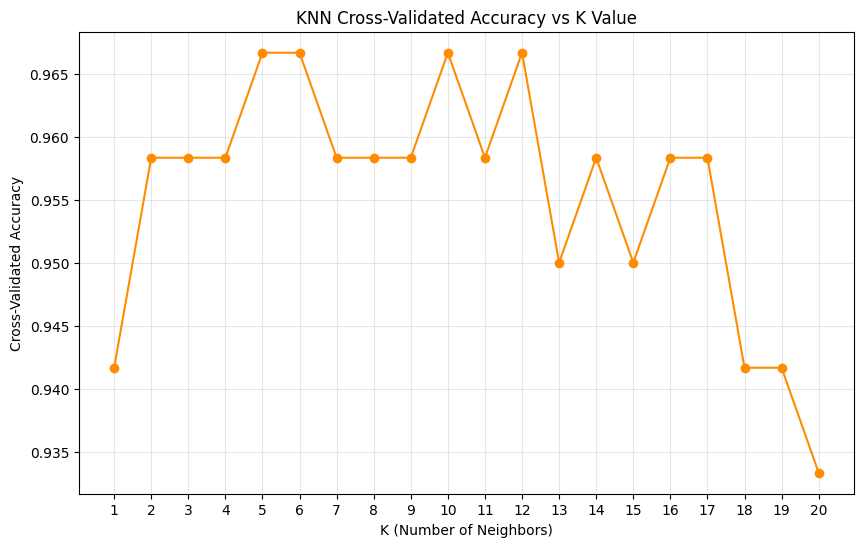

Best K: 5, Best CV Accuracy: 0.9667


In [ ]:
# Plot CV Accuracy vs K
plt.figure(figsize=(10,6))
plt.plot(k_values, cv_accuracies, marker="o", linestyle="-", color="darkorange")
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("KNN Cross-Validated Accuracy vs K Value")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

best_k = k_values[np.argmax(cv_accuracies)]
print(f"Best K: {best_k}, Best CV Accuracy: {max(cv_accuracies):.4f}")

In [ ]:
# Final test accuracy comparison: No-CV best K vs CV best K

# --- Approach 1: No CV (best K found from single train/test split accuracy) ---
best_k_no_cv = k_values[np.argmax(accuracies)]   # from your original loop (the "accuracies" list)

knn_no_cv = KNeighborsClassifier(n_neighbors=best_k_no_cv)
knn_no_cv.fit(X_train_scaled, y_train)
test_acc_no_cv = accuracy_score(y_test, knn_no_cv.predict(X_test_scaled))

print(f"No-CV Approach -> Best K: {best_k_no_cv}, Final Test Accuracy: {test_acc_no_cv:.4f}")


# --- Approach 2: With CV (best K found from 5-fold cross-validation) ---
best_k_cv = k_values[np.argmax(cv_accuracies)]   # from your CV loop (the "cv_accuracies" list)

knn_cv = KNeighborsClassifier(n_neighbors=best_k_cv)
knn_cv.fit(X_train_scaled, y_train)
test_acc_cv = accuracy_score(y_test, knn_cv.predict(X_test_scaled))

print(f"CV Approach     -> Best K: {best_k_cv}, Final Test Accuracy: {test_acc_cv:.4f}")


# --- Side-by-side comparison table ---
comparison_k = pd.DataFrame({
    "Approach": ["No Cross-Validation", "Cross-Validation"],
    "Best K Chosen": [best_k_no_cv, best_k_cv],
    "Final Test Accuracy": [test_acc_no_cv, test_acc_cv]
})

comparison_k

No-CV Approach -> Best K: 1, Final Test Accuracy: 0.9667
CV Approach     -> Best K: 5, Final Test Accuracy: 0.9333


,Approach,Best K Chosen,Final Test Accuracy
0,No Cross-Validation,1,0.966667
1,Cross-Validation,5,0.933333


**Final Summary**: The K-Nearest Neighbors (KNN) classifier was implemented on the Iris dataset after scaling the features using StandardScaler, as KNN is distance-based and sensitive to differences in feature scales. The effect of varying the number of neighbors (K = 1–20) was analyzed, showing consistently high classification accuracy across most K values due to the well-separated nature of the Iris dataset. To select the optimal value of K, both a simple train-test evaluation and 5-fold cross-validation were performed. While the no cross-validation approach achieved a slightly higher test accuracy by selecting the first K with the highest score, this method indirectly used the test set for hyperparameter selection. In contrast, cross-validation evaluated each K using only the training data, providing a more reliable estimate of model performance and selecting a more robust K value before the final evaluation on the unseen test set. Overall, the experiment demonstrated the importance of feature scaling for KNN, the influence of the choice of K on model performance, and the advantages of cross-validation as a more principled and unbiased approach to hyperparameter tuning.